In [50]:
import particles_mod.Icosphere as ico
import numpy as np
import matplotlib.pyplot as plt
import libMobility as lm
import pyvista as pv
pv.set_jupyter_backend('html')




In [51]:
num_particles = 80

radius = 5.0

density = num_particles / (4.0 * np.pi * radius**2)

icosphere = ico.IcoSphere(radius, density)


13/06/2025 16:55:27 - VLMP - INFO - [VLMP] Starting VLMP 
13/06/2025 16:55:27 - VLMP - DEBUG - [VLMP] Processing "system" component ({'type': 'simulationName', 'parameters': {'simulationName': 'Icosphere'}}), type "simulationName" (VLMP.py:194)
13/06/2025 16:55:27 - VLMP - WARNING - [VLMP] (system) Component name not specified, using "simulationName". 
13/06/2025 16:55:27 - VLMP - DEBUG - [VLMP] (system) Component name "simulationName". (VLMP.py:200)
13/06/2025 16:55:27 - VLMP - DEBUG - [VLMP] (system) Component parameters "{'simulationName': 'Icosphere'}" (VLMP.py:207)
13/06/2025 16:55:27 - VLMP - DEBUG - [VLMP] Processing "system" component ({'type': 'simulationName', 'parameters': {'simulationName': 'Icosphere'}}), type "simulationName" (VLMP.py:194)
13/06/2025 16:55:27 - VLMP - WARNING - [VLMP] (system) Component name not specified, using "simulationName". 
13/06/2025 16:55:27 - VLMP - DEBUG - [VLMP] (system) Component name "simulationName". (VLMP.py:200)
13/06/2025 16:55:27 - VLMP

In [52]:

print("Number of particles:", icosphere.nparticles)
print("Radius of the icosphere:", icosphere.radius)

Number of particles: 92
Radius of the icosphere: 5.0


In [53]:
modes, eigenvalues = icosphere.obtain_modes()


Preliminary simulation structure created


[WARNING] UAMMD-structured Python wrapper is not compatible with UAMMD-structured self restarting mechanism
[MESSAGE] ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
[MESSAGE] ╻ ╻┏━┓┏┳┓┏┳┓╺┳┓
[MESSAGE] ┃ ┃┣━┫┃┃┃┃┃┃ ┃┃ Version: 2.5
[MESSAGE] ┗━┛╹ ╹╹ ╹╹ ╹╺┻┛
[MESSAGE] Compiled at: May 23 2025 13:23:39
[MESSAGE] Compiled in double precision mode
[MESSAGE] Computation started at Fri Jun 13 16:55:27 2025

[MESSAGE] [System] CUDA initialized
[MESSAGE] [System] Using device: NVIDIA GeForce RTX 3080 with id: 0
[MESSAGE] [System] Compute capability of the device: 8.6
[MESSAGE] ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ 
[MESSAGE] [ExtendedSystem] (system) Name: Icosphere
[MESSAGE] [ExtendedSystem] (system) Seed: 1749826527837043435
[MESSAGE] [GlobalDataBase] Fundamental not specified, using default fundamental, "Time"
[WARNING] [Time] No timeStep specified, using 0.0 as default.
[MESSAGE] [Basic] Loaded type A, mass: 1.000000, radius: 0.500000, charge: 0.000000
[MES

Read Hessian file /tmp/tmpkpiiip63/hessian.txt with shape (8464, 11)


In [54]:

def plot_positions(positions, radius=1.0):
    """
    Plot the positions of particles in 3D.
    Args:
        positions: Array of particle positions.
        radius: Radius of the spheres representing particles.
    """
    plotter = pv.Plotter()
    for pos in positions:
        sphere = pv.Sphere(radius=radius, center=pos)
        plotter.add_mesh(sphere, color='blue', opacity=0.5)
    plotter.window_size = [400, 400]
    plotter.show()

plot_positions(icosphere.positions, radius=1)


EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

In [55]:

precision = np.float32 if lm.SelfMobility.precision == "float" else np.float64

def create_solver(model: str = "SelfMobility", wallHeight: float = 0.0):
    """
    Create a solver based on the specified model.
    Args:
        model: The model to use for the solver. Options are "SelfMobility" or "NBody".
    Returns:
        solver: An instance of the solver for the specified model.
    """

    if model == "SelfMobility":
        solver = lm.SelfMobility("open", "open", "open")
        solver.setParameters(5)
    elif model == "NBody":
        solver = lm.NBody("open", "open", "open")
        solver.setParameters()
    elif model == "NBodywall":
        solver = lm.NBody("open", "open", "single_wall")
        solver.setParameters(wallHeight = wallHeight)
    
    solver.initialize(
        temperature=0.0,
        viscosity=1/(6 * np.pi),
        hydrodynamicRadius=1.0,
        needsTorque=False,
    )
    return solver

def create_forces_from_modes(modes, eigenvalues):
    forces = - modes * eigenvalues.T
    return forces

def reconstruct_rigid_modes(modes, coupling_matrix):
    """
    Reconstruct the rigid modes from the given modes and coupling matrix.
    Args:
        modes: The modes to reconstruct.
        coupling_matrix: The coupling matrix to use for reconstruction.
    Returns:
        new_modes: The reconstructed modes.
    """
    rotation_eigenvalues, rotation_eigenvectors = np.linalg.eigh(coupling_matrix[:3, :3])
    assert rotation_eigenvectors.shape == (3, 3), f"Rotation eigenvectors should be a 3x3 matrix, got {rotation_eigenvectors.shape}"
    traslation_eigenvalues, traslation_eigenvectors = np.linalg.eigh(coupling_matrix[3:6, 3:6])
    assert traslation_eigenvectors.shape == (3, 3), f"Translation eigenvectors should be a 3x3 matrix, got {traslation_eigenvectors.shape}"
    rotation_modes = modes[:, :3] @ rotation_eigenvectors
    assert rotation_modes.shape == modes[:, :3].shape, f"Rotation modes should have the same shape as the first three columns of modes, got {rotation_modes.shape} and {modes[:, :3].shape}"
    traslation_modes = modes[:, 3:6] @ traslation_eigenvectors
    new_modes = np.copy(modes)
    new_modes[:, :3] = rotation_modes
    new_modes[:, 3:6] = traslation_modes

    return new_modes

def coupling_matrix_from_modes(modes, solver, forces_method = "modes"):
    """
    
    """
    if forces_method not in ["modes", "elastic"]:
        raise ValueError("forces_method must be either 'modes' or 'elastic'")

    coupling_matrix = np.zeros((icosphere.nparticles * 3, icosphere.nparticles * 3), dtype=precision)
    for mode_index in range(modes.shape[1]):
        if forces_method == "modes":
            force = modes[:, mode_index].reshape((icosphere.nparticles, 3))
        elif forces_method == "elastic":
            force = create_forces_from_modes(modes[:, mode_index].reshape((icosphere.nparticles, 3)), eigenvalues[mode_index])
        velocity = solver.Mdot(forces=force)[0]
        coupling_matrix[:, mode_index] = velocity.reshape((icosphere.nparticles * 3,))
    coupling_matrix = modes.T @ coupling_matrix

    return coupling_matrix

def construct_coupling_matrix(modes, solver, forces_method = "modes"):
    coupling_matrix =  coupling_matrix_from_modes(modes, solver, forces_method)
    new_modes = reconstruct_rigid_modes(modes, coupling_matrix)
    coupling_matrix =  coupling_matrix_from_modes(new_modes, solver, forces_method)
    return coupling_matrix, new_modes
        
def plot_coupling_matrix(coupling_matrix, nummodes = 25):
    """
    Plot the mobility matrix as a heatmap.
    Args:
        coupling_matrix: The mobility matrix to plot.
    """
    plt.figure()
    plt.imshow(coupling_matrix[:nummodes,:nummodes], cmap='seismic', vmax=3, vmin=-3, 
               interpolation='None')
    plt.title("Mobility Matrix")
    plt.xlabel("Excitation modes")
    plt.ylabel("Excited modes")
    plt.colorbar()
    plt.show()

def plot_diagonal(coupling_matrix):
    """
    Plot the diagonal of the mobility matrix.
    Args:
        coupling_matrix: The mobility matrix to plot.
    """
    plt.scatter(range(coupling_matrix.shape[0]), coupling_matrix.diagonal(), s=1)
    plt.title("Diagonal of Mobility Matrix")
    plt.xlabel("Mode Index")
    plt.ylabel("Diagonal Value")
    plt.grid()

def plot_mode(positions : list, eigenmode: np.ndarray):
    """
    Plot the eigenmode of the Hessian matrix.
    :param positions: A list of tuples containing the x, y and z coordinates of each particle.
    :param eigenvectors: A numpy array containing the eigenmode data in (nparticles, 3) format.
    :param mode: The index of the eigenmode to plot.
    """

    new_positions = np.array(positions) + np.array(eigenmode)   # Scale the eigenmode for visualization

    mesh = pv.PolyData(new_positions)
    mesh = mesh.delaunay_3d()
    mesh['Eigenvector'] = eigenmode  # Add the eigenmode as a scalar field for coloring
    p = pv.Plotter()
    p.add_mesh(mesh, scalars='Eigenvector', show_scalar_bar=True, show_edges=False, cmap='coolwarm')
    p.add_arrows(np.array(positions), eigenmode / np.max(np.linalg.norm(eigenmode, axis=1))*2, color='blue', opacity=0.95
                 , name='Eigenvector Arrows')
    p.window_size = [300, 250]
    # add the coordinate triad bigger
    p.add_axes(interactive=True, line_width=5, labels_off=False, color='black')
    p.show()



positions = icosphere.positions.astype(precision)

solver = create_solver("NBodywall", np.min(icosphere.positions[:, 2]) - 2.0)
solver.setPositions(positions)

coupling_matrix, new_modes = construct_coupling_matrix(modes, solver)

print("Coupling matrix symmetry check (wall):", np.allclose(coupling_matrix, coupling_matrix.T, atol=1e-5))





Coupling matrix symmetry check (wall): True


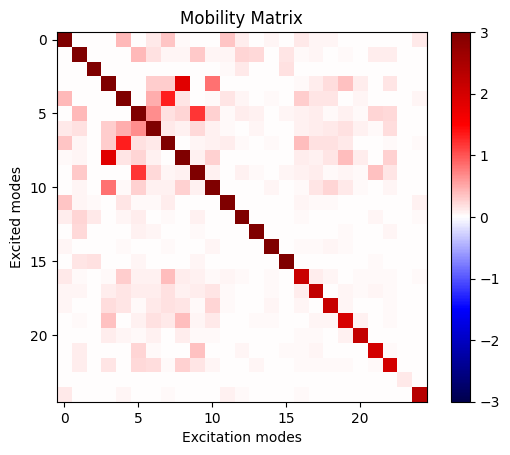

first 6 x 6 coupling matrix elements:
[[ 6.388 -0.    -0.    -0.    -0.403  0.   ]
 [-0.     6.39  -0.     0.     0.     0.403]
 [-0.    -0.     7.044  0.     0.     0.   ]
 [ 0.     0.     0.     5.433  0.    -0.   ]
 [-0.403  0.     0.     0.    10.454  0.   ]
 [ 0.     0.403  0.    -0.    -0.    10.455]]


In [56]:
plot_coupling_matrix(np.abs(coupling_matrix), nummodes=25)

print("first 6 x 6 coupling matrix elements:")
np.set_printoptions(precision=3, suppress=True)
print(coupling_matrix[:6, :6])


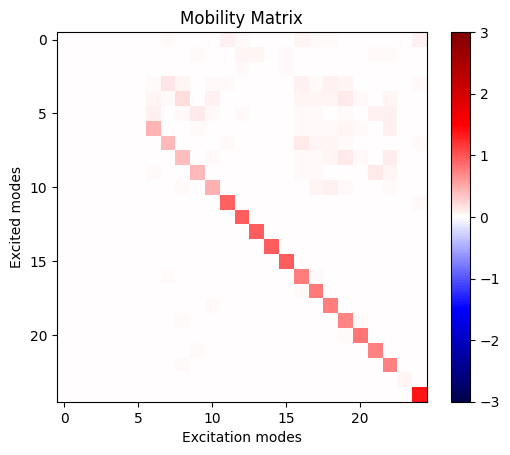

first 6 x 6 coupling matrix elements (elastic):
Coupling matrix symmetry check (after scaling): False
First 6 eigenvalues of the scaled coupling matrix: [-23.7830984155 -22.2907516286 -22.2675572198 -22.1147390114
 -19.8848211445 -19.8720847039]
Scaled eigenvalues: [-23.7830984155 -22.2907516286 -22.2675572198 -22.1147390114
 -19.8848211445 -19.8720847039 -19.8456898487 -19.707205326
 -19.6954208888 -18.5778020128 -18.4983163401 -18.3918015102
 -16.3447063676 -16.3284929631 -16.2522876514 -15.9391127
 -15.9302441836 -15.9047542258 -15.6227327866 -12.3909967583
 -12.3729011661 -12.354036222  -12.2616785038 -10.8097592632
 -10.804423659  -10.801732389  -10.798067407  -10.7923063046
 -10.7721711313 -10.7555054169 -10.6065558473 -10.5071221477
 -10.3032525645 -10.2931176239 -10.2772990837 -10.2351759479
 -10.1517581992  -9.2491131169  -9.2347286518  -9.2078538682
  -9.134492508   -9.1192989166  -9.0359053227  -7.6553887194
  -7.6509229332  -7.6355510562  -7.6079807877  -7.5551117941
  -7.2

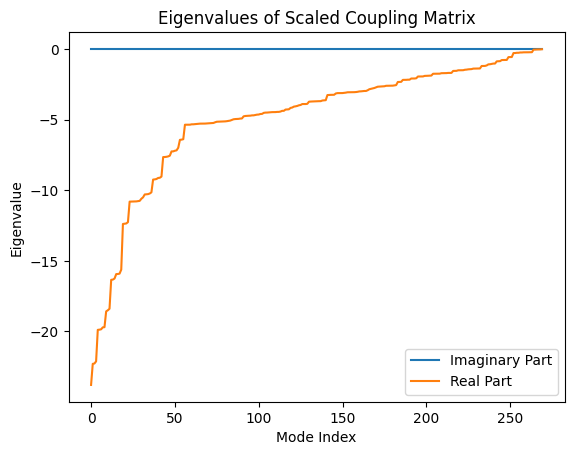

In [58]:
coupling_matrix_el, elastic_modes = construct_coupling_matrix(modes, solver, forces_method="elastic")
plot_coupling_matrix(np.abs(coupling_matrix_el), nummodes=25)
print("first 6 x 6 coupling matrix elements (elastic):")
np.set_printoptions(precision=3, suppress=True)

# diagonalize the coupling matrix
coupling_eigenvalues, coupling_eigenvectors = np.linalg.eig(coupling_matrix_el)

scaled_matrix = coupling_matrix_el @ np.diag(eigenvalues)

symmetry_check = np.allclose(scaled_matrix, scaled_matrix.T, atol=1e-5)
print("Coupling matrix symmetry check (after scaling):", symmetry_check)


scaled_eigenvalues, scaled_eigenvectors = np.linalg.eig(scaled_matrix[6:, 6:])
scaled_eigenvalues = np.sort(scaled_eigenvalues)

np.set_printoptions(precision=10, suppress=True)
print("First 6 eigenvalues of the scaled coupling matrix:", scaled_eigenvalues[:6])

print("Scaled eigenvalues:", scaled_eigenvalues)
plt.figure()
plt.plot(np.imag(scaled_eigenvalues), label='Imaginary Part')
plt.plot(np.real(scaled_eigenvalues), label='Real Part')
plt.title("Eigenvalues of Scaled Coupling Matrix")
plt.xlabel("Mode Index")
plt.ylabel("Eigenvalue")
plt.legend()


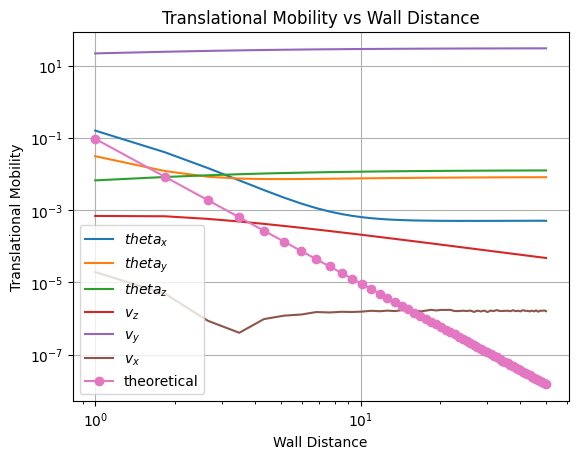

In [ ]:
def tt_mobility(wall_distance):
    solver = create_solver("NBodywall", np.min(icosphere.positions[:, 2]) - wall_distance)
    solver.setPositions(positions)
    coupling_matrix = construct_coupling_matrix(modes, solver)
    return coupling_matrix[4,:6]

wall_distances = np.linspace(1.0, 50.0, 60) *radius
tt_mobilities = [tt_mobility(d) for d in wall_distances]
plt.figure()
# normalized by the value at the minimum wall distance
plt.plot(wall_distances/radius, np.abs(tt_mobilities))
plt.plot(wall_distances/radius, 3/(wall_distances/radius)**4/32, marker='o')
plt.legend(['$theta_x$', '$theta_y$', '$theta_z$', '$v_z$', '$v_y$', '$v_x$', 'theoretical'])
plt.title("Translational Mobility vs Wall Distance")
plt.xlabel("Wall Distance")
plt.ylabel("Translational Mobility")
plt.xscale('log')
plt.yscale('log')
plt.grid()
plt.show()


In [ ]:

for i in range(6):
    plot_mode(icosphere.positions, modes[:, i].reshape((icosphere.nparticles, 3)))

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

2025-06-13 13:00:28.986 (  11.625s) [    7F8B5CF275C0]            vtkMath.cxx:570   WARN| Unable to factor linear system
2025-06-13 13:00:28.986 (  11.626s) [    7F8B5CF275C0]            vtkMath.cxx:570   WARN| Unable to factor linear system
2025-06-13 13:00:28.988 (  11.627s) [    7F8B5CF275C0]      vtkDelaunay3D.cxx:513   WARN| vtkDelaunay3D (0x55c2540a3180): 2 degenerate triangles encountered, mesh quality suspect


EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

2025-06-13 13:00:29.089 (  11.729s) [    7F8B5CF275C0]      vtkDelaunay3D.cxx:513   WARN| vtkDelaunay3D (0x55c254a52790): 22 degenerate triangles encountered, mesh quality suspect


EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

In [ ]:
plot_mode(icosphere.positions, modes[:, 23].reshape((icosphere.nparticles, 3)))

2025-06-13 13:00:29.377 (  12.016s) [    7F8B5CF275C0]      vtkDelaunay3D.cxx:513   WARN| vtkDelaunay3D (0x55c255dbde10): 1 degenerate triangles encountered, mesh quality suspect


EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

136
474


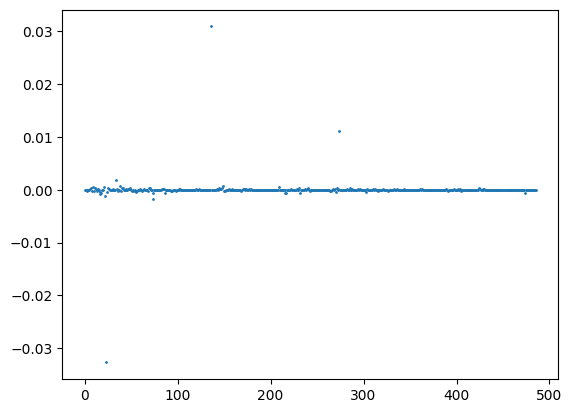

In [ ]:
print(np.argmax(coupling_matrix[:, 23]))
print(np.argmax(-coupling_matrix[23, :]))
plt.figure()
plt.scatter(range(coupling_matrix.shape[0]), coupling_matrix[:, 23], s=1)
plt.show()

In [ ]:
plot_mode(icosphere.positions, modes[:,136].reshape((icosphere.nparticles, 3)))

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…